In [1]:
# imports generally useful throughout the notebook
# usually all imports should happen at the top of a notebook, but in
# these notebooks where the purpose is to show how to use the Keras API
# the relevant imports will happen in the cells where the API is discussed
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import random

# project function imports used in notebook
# NOTE: requires PYTHONPATH to be set correctly
from nndl import vectorize_samples, plot_history

# global settings for notebook output and images
plt.rcParams['figure.figsize'] = (8, 8) # set default figure size, 10in by 8in
np.set_printoptions(precision=4, suppress=True)

In [2]:
# if want to restrict to cpu or gpu, configure visible device for rest of notebook to use
#dev = tf.config.list_physical_devices()
#print('Physical Devices : ', dev)

#tf.config.set_visible_devices(dev[0])
#tf.config.set_visible_devices(dev[1])
#dev = tf.config.list_logical_devices()
#print('Available Devices : ', dev)

# Chapter 9: Advanced Deep Learning for Computer Vision

Supporting materials for:

Chollet (2021). *Deep Learning with Python*. 2nd ed. Manning Publications Co.
[Amazon](https://www.amazon.com/Learning-Python-Second-Fran%C3%A7ois-Chollet/dp/1617296864/ref=sr_1_1?crid=32NFM2SBCJVQQ)

We previously introduced you to the basic components of a convnet and how convolutional and maxpooling layers
work.  We looked at some simple deep learning models for computer vision, stacks of `Conv2D` and `MaxPooling2D` layers.

In this section we will look at other types of computer vision tasks than image classification.

## 9.4 Interpreting what Convnets Learn

Techniques for visualizing convnet representations:

- **visualizing intermediate convnet outputs (intermediate activations)** Useful for understanding
  how successive convnet layers transform their input, and meaning of convnet filters.
- **visualizing convnet filters** Useful for understanding precisely what visual pattern or concept each filter in a convnet is
  receptive to.
- **visualizing heatmaps of class activation in an image** Useful for understanding which parts of an image were 
  identified as belonging to a given class.

### 9.4.1 Visualizing Intermediate Activations

Visualizing intermediate activations consists of displaying the values returned by various
convolution and pooling layers in a model, given a certain input.

This gives a view into how an input is decomposed into the different filters learned by the network.

We want to visualize feature maps with three dimensions: width, height, and depth (channels).
Each channel encodes relatively independent features, so the proper way to visualize
these feature maps is by independently plotting the contents of every channel as a 2D
image.

Lets start by modeling the final model with data augmentation we saved in from the
previous section.  This model used data augmentation and achieved around 82-83% on
the cats vs. dogs dataset.

In [3]:
model = keras.models.load_model("../models/ch08-convnet-from-scratch-with-augmentation.keras")
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 41, 41, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 18, 18, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 7, 7, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │        12,545 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,982,084 (7.56 MB)

 Trainable params: 991,041 (3.78 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 991,043 (3.78 MB)

Next, we'll get an input image - a picture of a cat, not part of the images the network
was trained on.

In [4]:
# download file to use from an amazonaws bucket
img_path = keras.utils.get_file(
    fname="cat.jpg",
    origin="https://img-datasets.s3.amazonaws.com/cat.jpg")

print(img_path)

80329/80329 ━━━━━━━━━━━━━━━━━━━━ 0s 3us/step
/home/vscode/.keras/datasets/cat.jpg


In [5]:
def get_img_array(img_path, target_size):
    """Given an image on disk, load it and turn into
    a numpy array suitable to be used by our model.
    """
    # opens the image and resizes it to the target size for us
    img = keras.utils.load_img(img_path, target_size=target_size)

    # turn image into a float32 NumPy array of shape (180, 180, 3)
    array = keras.utils.img_to_array(img)
    # add a dimension to transform into a "batch" of a single sample, with shape
    # (1, 180, 180, 3)
    array = np.expand_dims(array, axis=0)
    return array

img_tensor = get_img_array(img_path, target_size=(180, 180))
print(type(img_tensor))
print(img_tensor.shape)

<class 'numpy.ndarray'>
(1, 180, 180, 3)


Here is the picture we are using for this visualization.

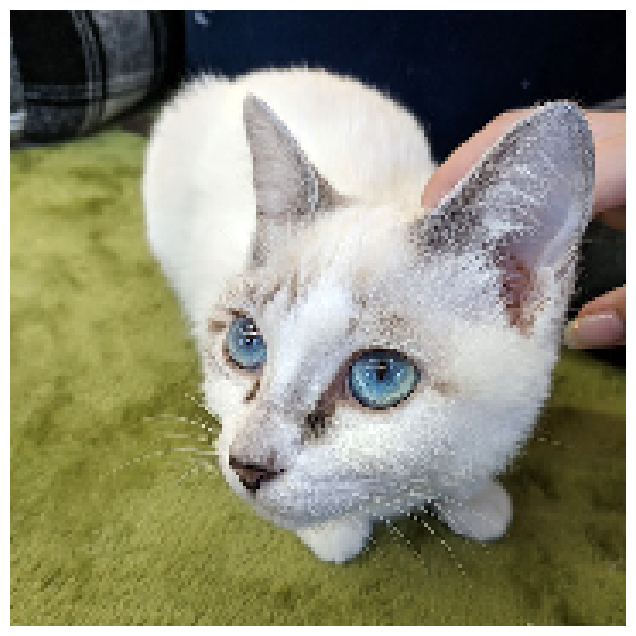

In [6]:
plt.axis("off")
plt.imshow(img_tensor[0].astype("uint8"))

In order to extract the feature maps we want to look at, we'll create a Keras
model that takes batches of images as input, and that outputs the activations of all
convolution and pooling layers!

In [7]:
layer_outputs = []
layer_names = []
for layer in model.layers:
    # extract output of all Conv2D and MaxPooling2D layers and put in a list
    if isinstance(layer, (layers.Conv2D, layers.MaxPooling2D)):
        # get the layer weights
        layer_outputs.append(layer.output)
        # also the corresponding layer names so we know which layer they come from
        layer_names.append(layer.name)

# create a model that will return these outputs given the model input
activation_model = keras.Model(inputs=model.input, outputs=layer_outputs)

This is a bit magical Keras API, we are reusing things from inside of the trained model.  The
new `activation_model` when given an input, will send it through the trained model, and the outputs
will be just the outputs of the layers we plucked out in the loop so that we can examine them.

When fed an image input, this model returns the values of the
later activations in the original model as a list.  This is the first time we've seen
a multi-output model, until now all of our examples had 1 input and 1 output.

This one has an input and nine output: one output per layer activation for the layers we want to visualize.

Lets get the layer activations for our sample input image.

In [8]:
# return a list of nine NumPY arrays: one array per layer activation
activations = activation_model.predict(img_tensor)

print(len(activations))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step
9


For instance this is the activation of the first convolution layer for the example cat
image input:

In [9]:
print(layer_names[0])
first_layer_activation = activations[0]
print(first_layer_activation.shape)

conv2d_5
(1, 178, 178, 32)


It's a `178 x 178` feature map with 32 channels (the output from the first convolution layer).

Let's try plotting the fifth channel of the activation of the first convolution layer of our original
model.

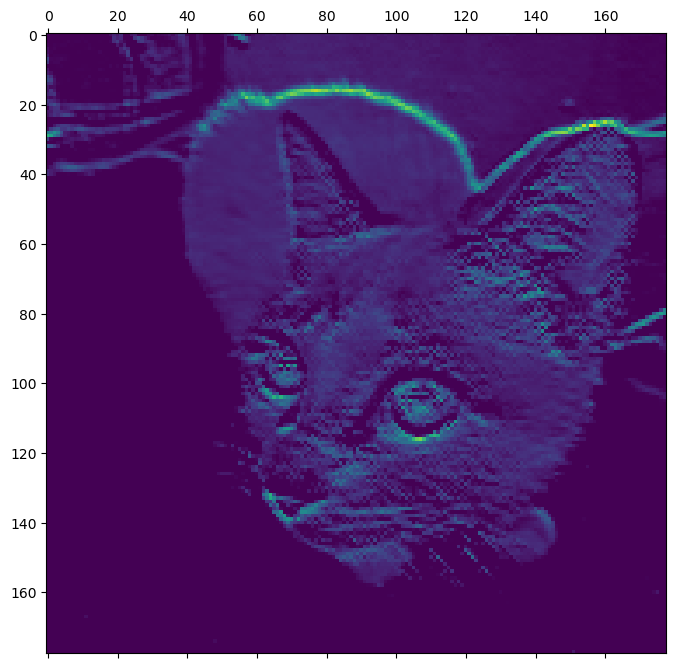

In [10]:
plt.matshow(first_layer_activation[0, :, :, 6], cmap="viridis")

What the channel we picked encodes will vary, so I can't say for certain what you will see.  The bright
colors are where the particular filter chosen is responding.  Usually they will be bright
around features like horizontal, vertical or diagonal edge.

Now let's plot a complete visualization of all the activations in the network.  We'll extract and plot
every channel in each of the layer activations and stack the results in one big grid with channels
stacked side by side.

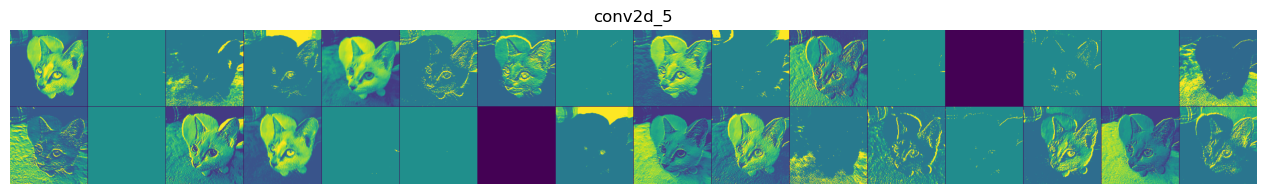

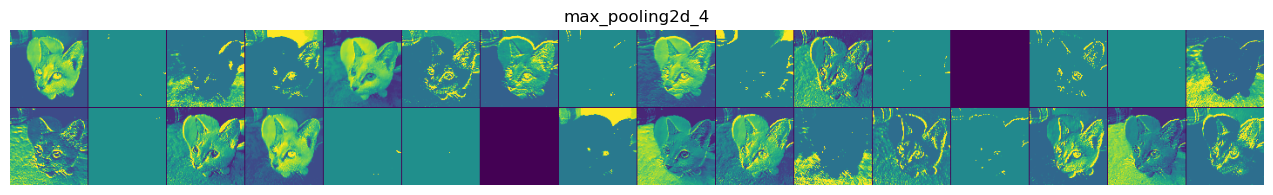

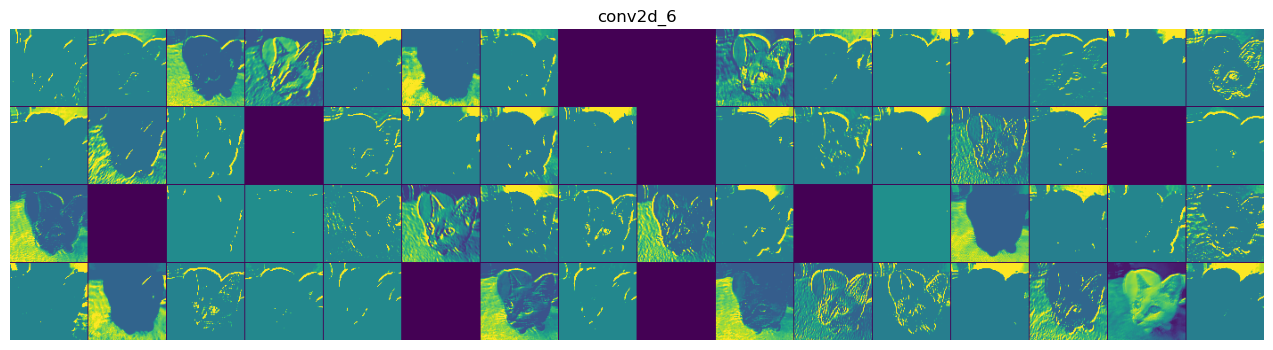

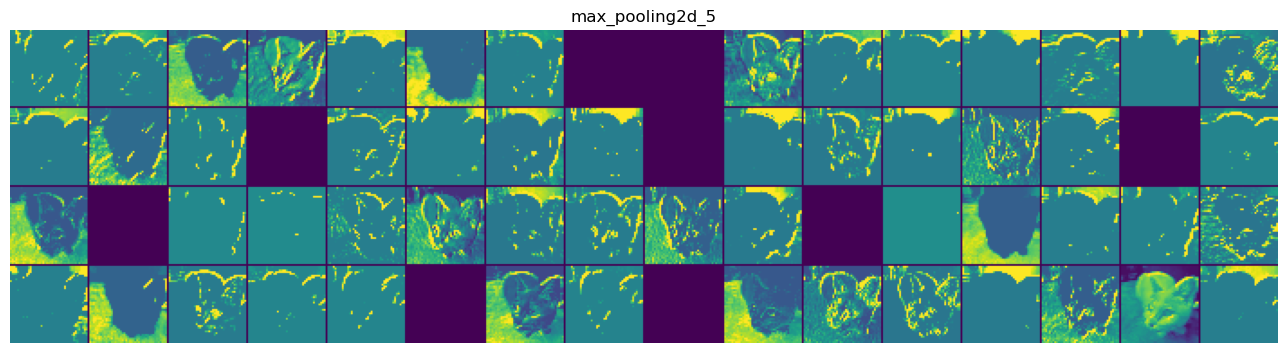

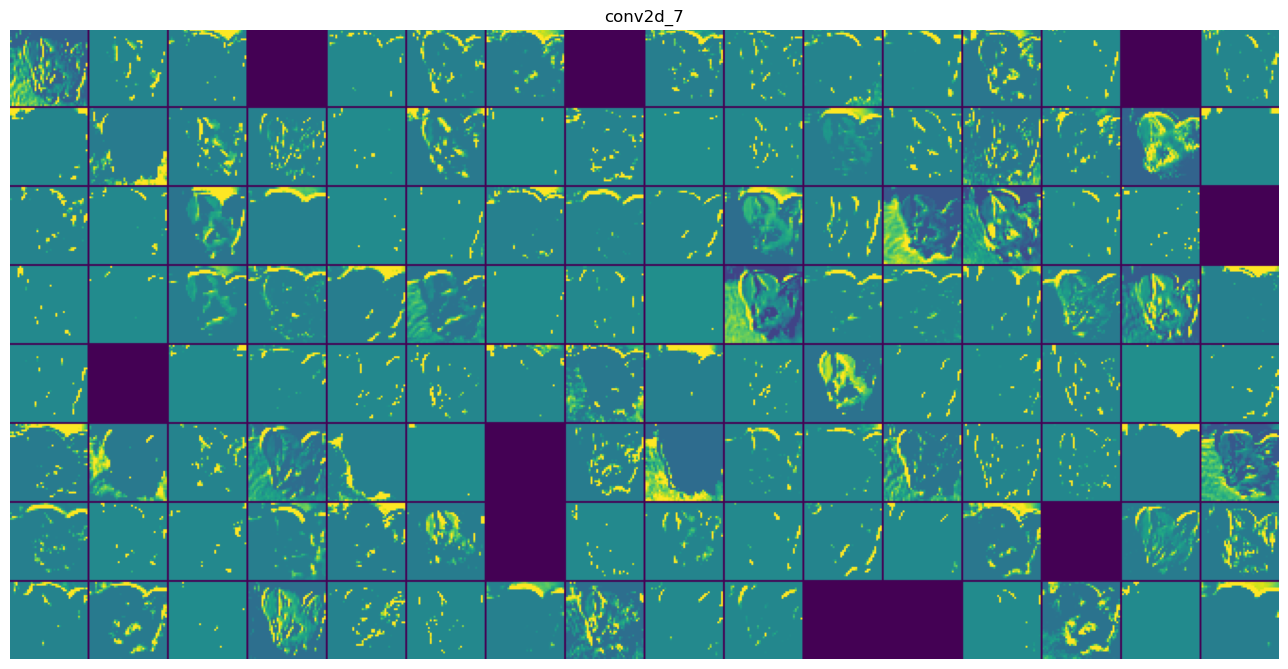

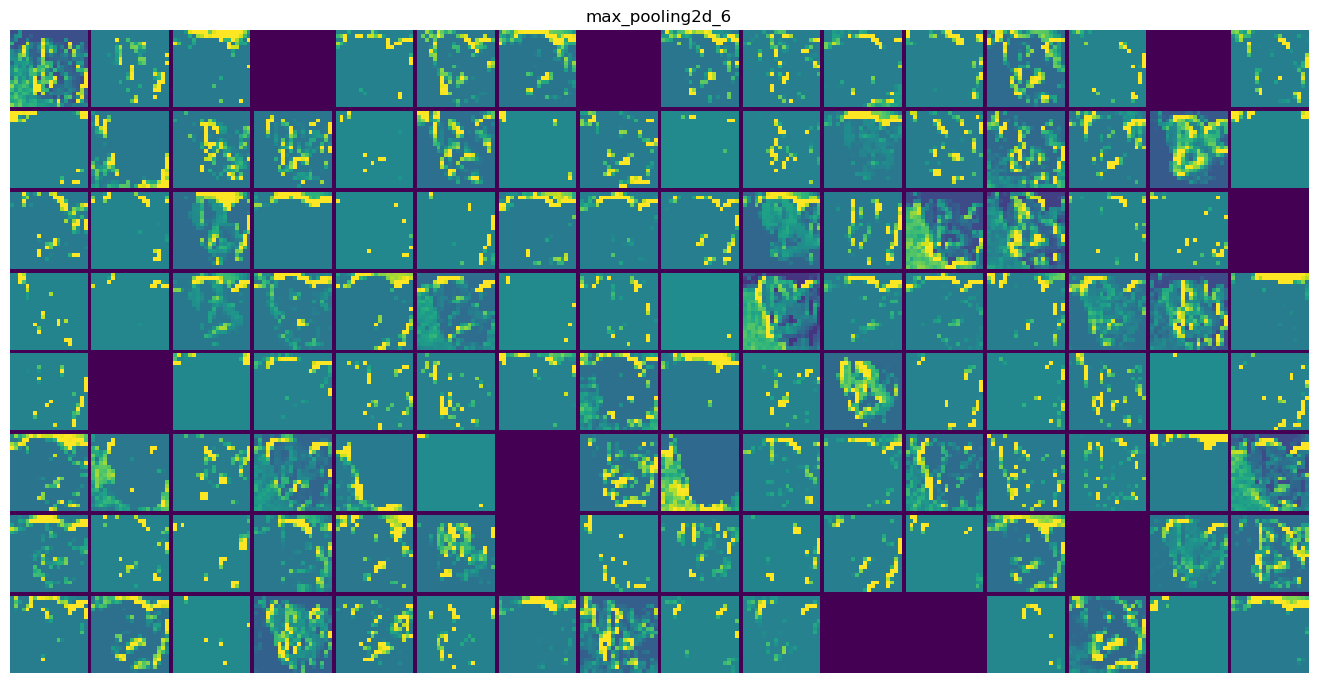

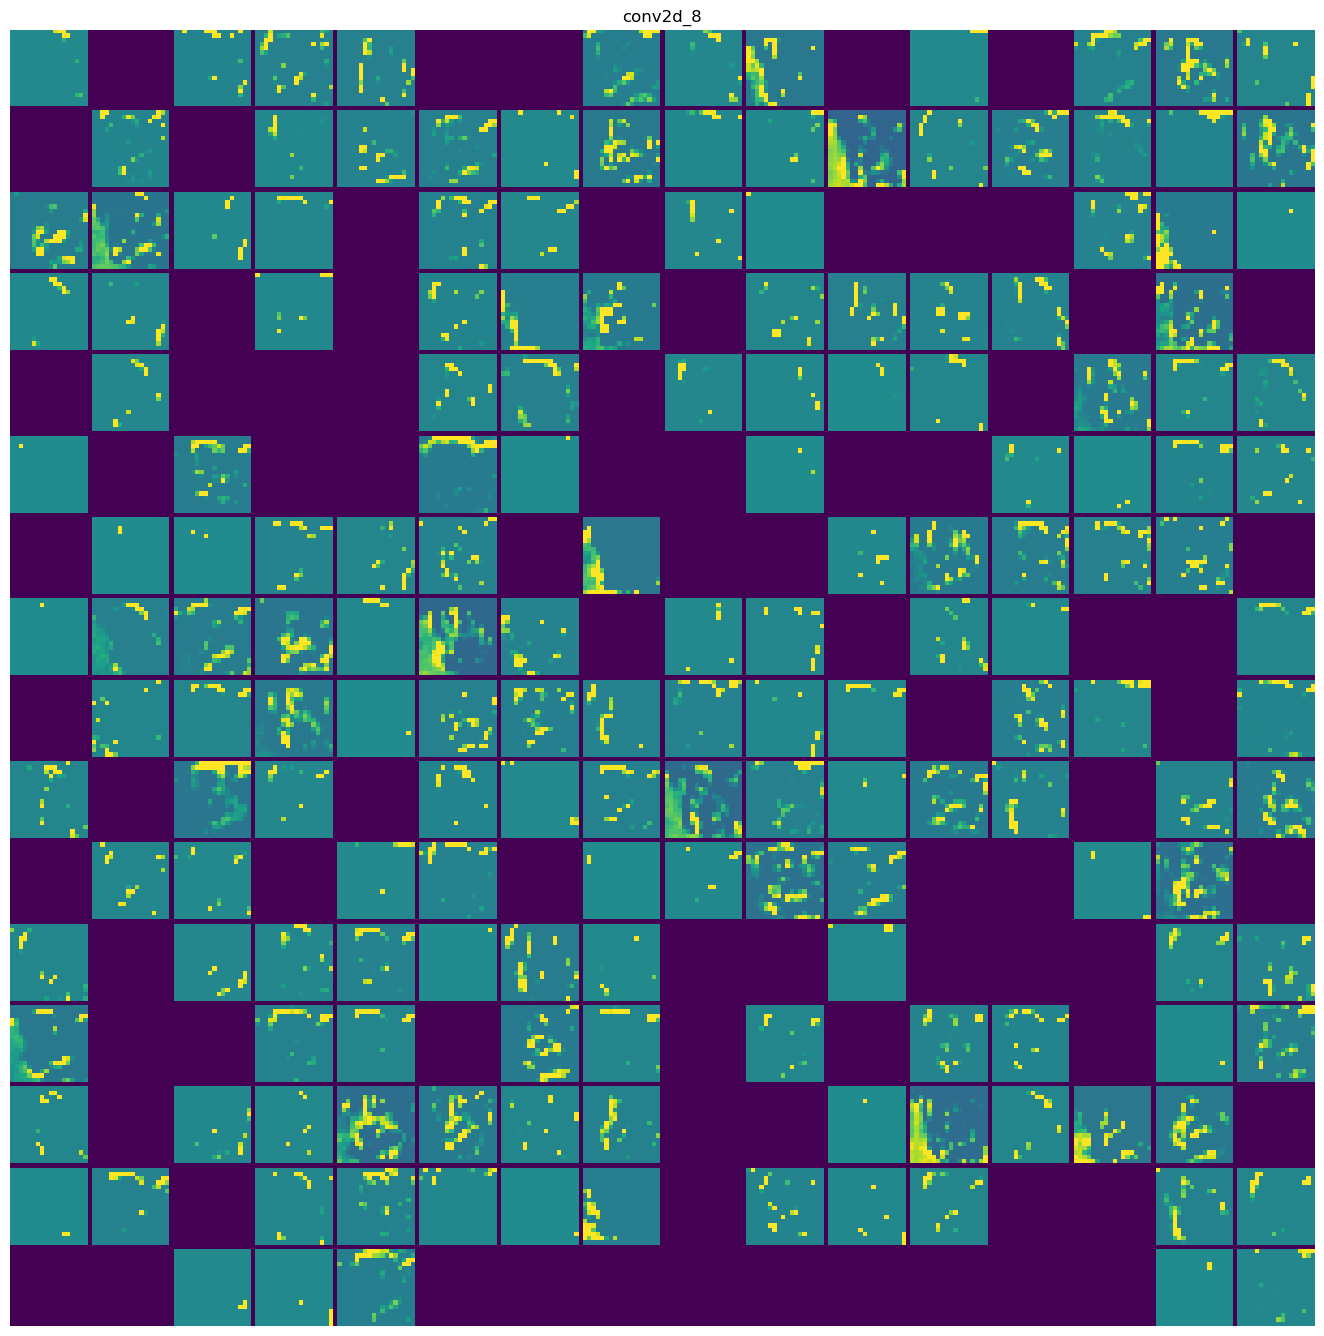

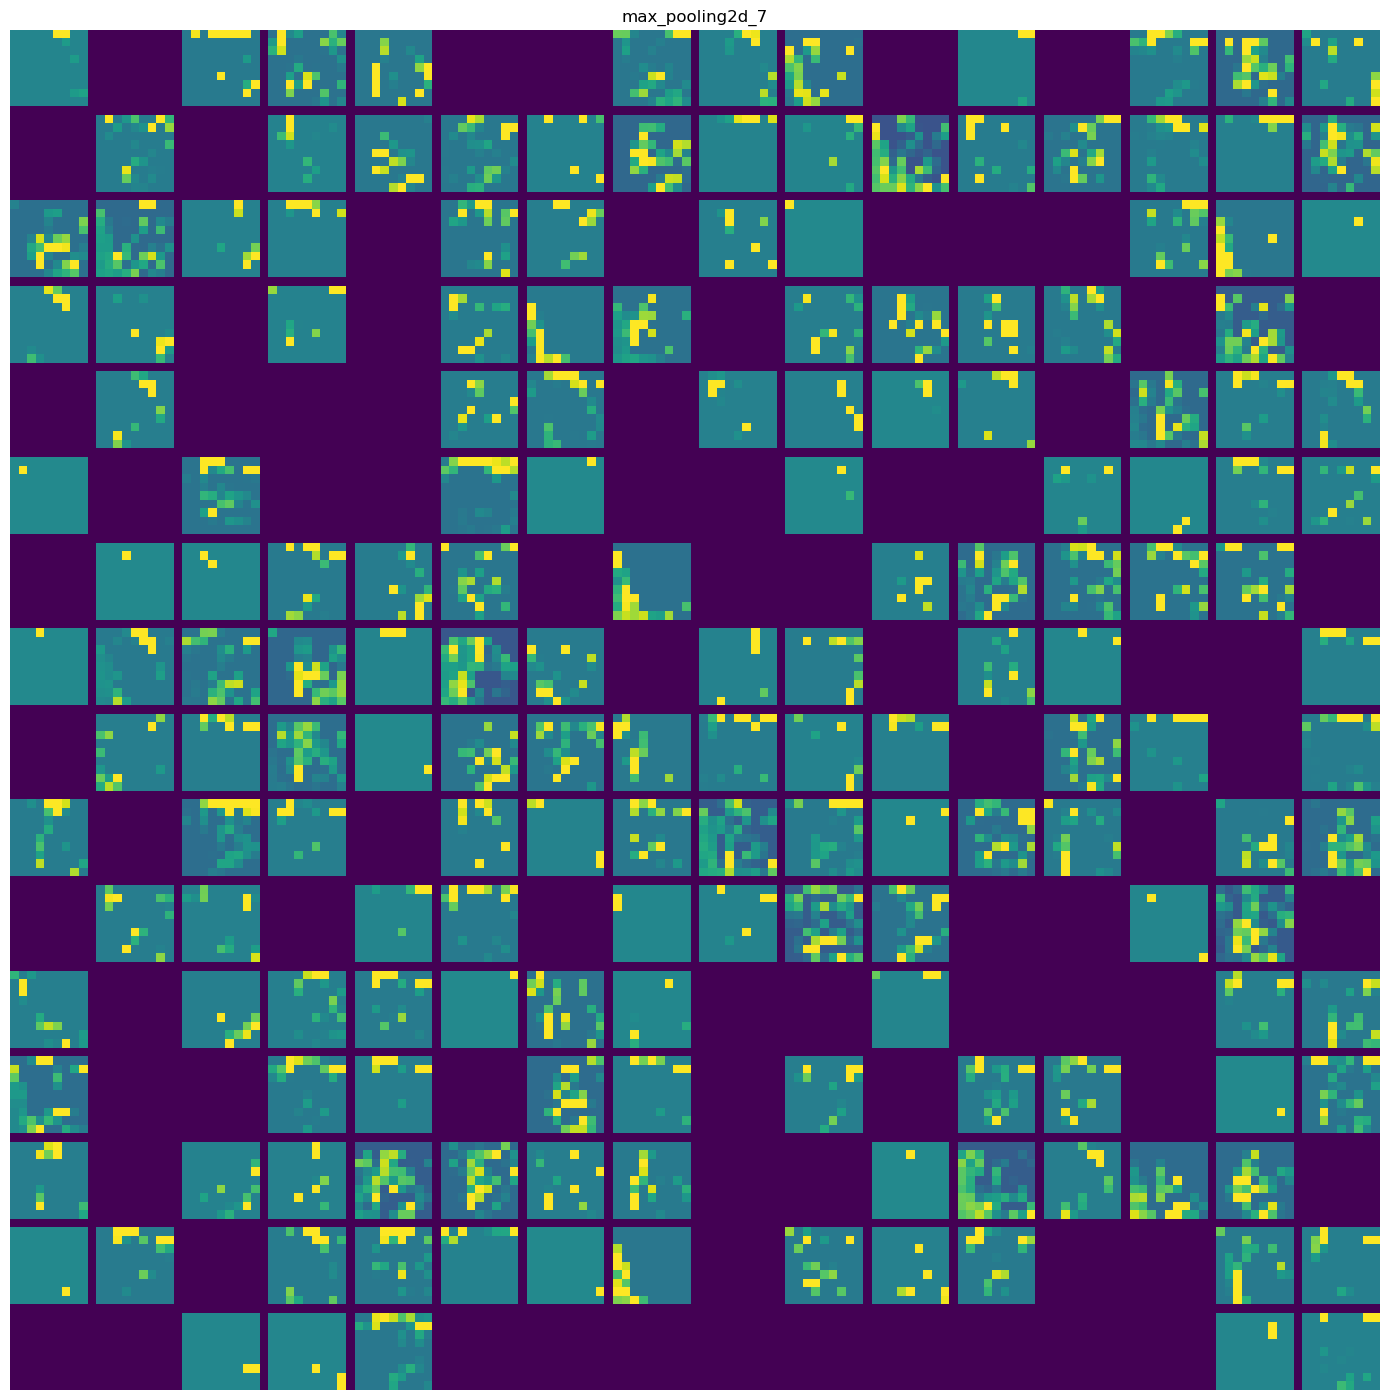

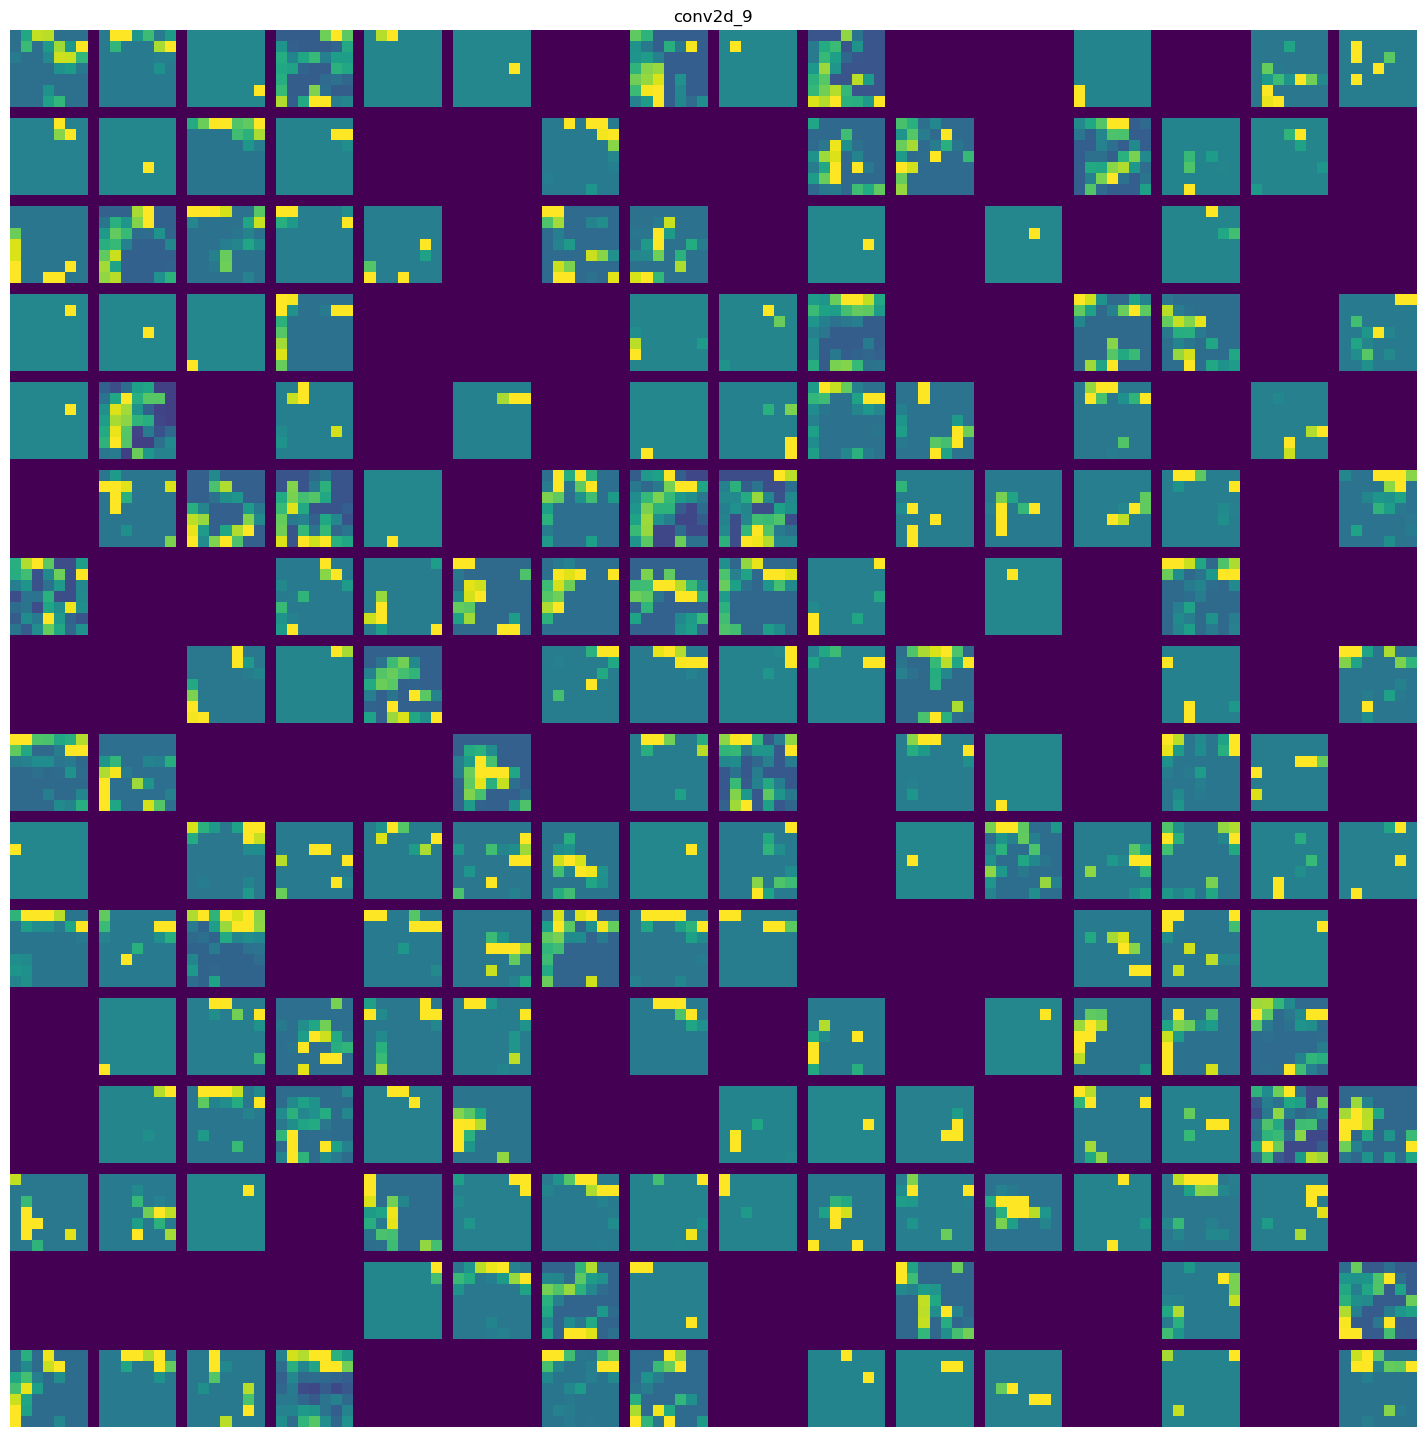

In [11]:
images_per_row = 16

# iterate over the activation layers (and the names of the corresponding layers)
for layer_name, layer_activation in zip(layer_names, activations):
    # this layer activation has shape (1, size, size, n_features)
    n_features = layer_activation.shape[-1]
    size = layer_activation.shape[1]
    n_cols = n_features // images_per_row
    # prepare an empty grid for displaying all channels in this activation
    display_grid = np.zeros(((size + 1) * n_cols - 1, images_per_row * (size + 1) - 1))

    for col in range(n_cols):
        for row in range(images_per_row):
            channel_index = col * images_per_row + row
            # this is a single channel or feature
            channel_image = layer_activation[0, :, :, channel_index].copy()

            # normalize channel values within the [0,255] range.  All zero channels are kept at 0
            if channel_image.sum() != 0:
                channel_image -= channel_image.mean()
                channel_image /= channel_image.std()
                channel_image *= 64
                channel_image += 128

            channel_image = np.clip(channel_image, 0, 255).astype("uint8")
            # place the channel image matrix in the empty grid we prepared
            display_grid[
                col * (size + 1): (col + 1) * size + col,
                row * (size + 1) : (row + 1) * size + row] = channel_image

    # display the grid for the layer
    scale = 1. / size
    plt.figure(figsize=(scale * display_grid.shape[1], scale * display_grid.shape[0]))
    plt.title(layer_name)
    plt.grid(False)
    plt.axis("off")
    plt.imshow(display_grid, aspect="auto", cmap="viridis")

There are a few things to note her:

- The first layer acts as a collection of various edge detectors. At that stage, the
  activations retain almost all of the information present in the initial picture.
- As you go deeper, the activations become increasingly abstract and less visually
  interpretable. They begin to encode higher-level concepts such as “cat ear” and “cat eye.”
- Deeper layers carry increasingly less information about the visual contents of the image,
  and increasingly more information related to the class of the image.
- The sparsity of the activations increases with the depth of the layer: in the first
  layer, almost all filters are activated by the input image, but in the following layers,
  more and more filters are blank. This means the pattern encoded by the filter
  isn’t found in the input image.

The features extracted by a layer become increasingly abstract with the depth of the layer.

The activations of higher layers carry less and less information about the specific input
being seen, and more and more information about the target.

A deep neural network effectively acts as an information distillation pipeline, with raw data going in
(in this case, RGB pictures) and being repeatedly transformed so that irrelevant information
is filtered out (for example, the specific visual appearance of the image), and
useful information is magnified and refined (for example, the class of the image).

### 9.4.2 Visualizing Convnet Filters

Another easy way to inspect the filters learned by convnets is to display the visual pattern
that each filter is meant to respond to.  

This can be done with gradient ascent in
input space: applying gradient descent to the value of the input image of a convnet so as
to maximize the response of a specific filter, starting from a blank input image.

Here we will switch to the filters of a full Xception model, pretrained on
ImageNet.  

- Build a loss function that maximizes the value of a given filter in a given convolution layer
- Use stochastic gradient descent to adjust the values of the input image so as to maximize this
  activation value.

First we need to instantiate the Xception model, loaded with the pretrained weights from training
on the ImageNet dataset.

In [12]:
# the classification layers are irrelevant for this visualization, so we chop them off
model = keras.applications.xception.Xception(weights="imagenet", include_top=False)

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 233s 3us/step


We're interested in the convolutional layers of the model, the `Conv2D` and `SeparableConv2D` layers.  We'll
need to know their names so we can retrieve their outputs.

In [13]:
for layer in model.layers:
    if isinstance(layer, (keras.layers.Conv2D, keras.layers.SeparableConv2D)):
        print(layer.name)

block1_conv1
block1_conv2
block2_sepconv1
block2_sepconv2
conv2d
block3_sepconv1
block3_sepconv2
conv2d_1
block4_sepconv1
block4_sepconv2
conv2d_2
block5_sepconv1
block5_sepconv2
block5_sepconv3
block6_sepconv1
block6_sepconv2
block6_sepconv3
block7_sepconv1
block7_sepconv2
block7_sepconv3
block8_sepconv1
block8_sepconv2
block8_sepconv3
block9_sepconv1
block9_sepconv2
block9_sepconv3
block10_sepconv1
block10_sepconv2
block10_sepconv3
block11_sepconv1
block11_sepconv2
block11_sepconv3
block12_sepconv1
block12_sepconv2
block12_sepconv3
block13_sepconv1
block13_sepconv2
conv2d_3
block14_sepconv1
block14_sepconv2


You'll notice that the `SeparableConv2D` layers are all named with a prefix like `block5-` or `block12_`.  Xception is structured into
blocks, each containing several convolutional layers.

No let's create a second model that returns the output of a specific layer, a **feature extractor** model.  Because our model is a Functional API
model, it is inspectable, we can query the `output` of one of its layers and reuse it in a new model.

In [14]:
# create a feature extractor model
# we choose this layer, but can replace this to do same visualization
# on any particular convolution layer you desire
layer_name = "block3_sepconv1"
# this is the layer object we're interested in
layer = model.get_layer(name=layer_name)
# we use model.input and layer.output to create a model that
# given an input image, returns the output of our target layer
feature_extractor = keras.Model(inputs=model.input, outputs=layer.output)

To use this model, simply call it on some input data.  Xception requires inputs be preprocessed via the `preprocess_input` function.
And we are using our same example cat image from the previous section again.

In [15]:
activation = feature_extractor(keras.applications.xception.preprocess_input(img_tensor))
print(activation.shape)

(1, 44, 44, 256)


Now the tricky part.  We will use the feature extractor model to define a function
that returns a scalar value quantifying how much a given input image "activates" a given filter in the layer.
This is the "loss function" that we'll maximize during the gradient descent process.

Note: maximizing is correct here, this loss function is better for higher activations, so need to maximize the loss.

In [16]:
def compute_loss(image, filter_index):
    """This function takes an image tensor and the index of the
    filter we are considering.

    Parameters
    ----------
    image : tf tensor
      The image tensor, already assumed to be preprocessed for xception
    filter_index : int
      The index of the filter / channel we should computing loss on
    """
    activation = feature_extractor(image)
    # note we avoid border artifacts by only involving non-border pixels in the loss
    # we discard the first two pixels along the sides of the activation
    filter_activation = activation[:, 2:-2, 2:-2, filter_index]
    # our loss is the mean or average activation for image for the filter/channel we are examining
    return tf.reduce_mean(filter_activation)

Let's set up the gradient "ascent" step function, using a `GradientTape` (similar to our low level examples of
setting up a training loop by hand).  Note that
we'll use a `@tf.function` decorator to speed it up.

A non-obvious trick to help the gradient descent process go smoothly is to normalize the
gradient tensor by dividing it by its L2 norm (the square root of the
average of the square of the values in the tensor).  This ensures that the magnitude of the
update done to the input image is always within the same range.

In [17]:
@tf.function
def gradient_ascent_step(image, filter_index, learning_rate):
    with tf.GradientTape() as tape:
        # explicitly watch the image tensor, since it isn't a TensorFlow variable
        tape.watch(image)
        # compute the loss scalar, indicating how much the current image activates the filter
        loss = compute_loss(image, filter_index)

    # compute gradients of the loss with respect to the image
    grads = tape.gradient(loss, image)
    # apply the gradient normalization trick
    grads = tf.math.l2_normalize(grads)
    # move the image a little bit in a direction that activates our target more strongly
    # NOTE: because we are maximizing, we do a += to add in the lr * grads instead of subtract
    image += learning_rate * grads
    # return the updated image so we can run the stp function in a loop
    return image

Now we have all the pieces.  Create a Python function that takes a filter index, and returns a tensor representing
the pattern that maximizes the activation of the specified filter.

In [18]:
img_width = 200
img_height = 200

def generate_filter_pattern(filter_index):
    """Function to generate filter visualizations
    """
    # number of gradient ascent steps to apply
    iterations = 30
    # amplitude of a single step
    learning_rate = 10.
    # initialize image tensor with random values, centered around 0.5
    image = tf.random.uniform(minval=0.4, maxval=0.6, shape=(1, img_width, img_height, 3))
    # perform gradient ascent steps on the initially random image
    for i in range(iterations):
        image = gradient_ascent_step(image, filter_index, learning_rate)
    return image[0].numpy()

The resulting image tensor is a floating-point array of shape (200, 200, 3) with values that may not be integers with [0, 255].
Hence we need to post-process this tensor to turn it into a displayable image.

In [19]:
def deprocess_image(image):
    """Postprocess image with maximum response to a filter returned from
    generate_filter_pattern.  Need to normalize values, convert to integers
    and do a center crop to avoid border artifacts.
    """
    # normalize image values within the [0,255] range
    image -= image.mean()
    image /= image.std()
    image *= 64
    image += 128
    # convert to integer values
    image = np.clip(image, 0, 255).astype("uint8")
    # center crop avoids border artifacts
    image = image[25:-25, 25:-25, :]
    return image

Let's try it.  This process is has hardcoded the layer we are using, which was `layer_name = "block3_sepconv1"` in our `feature_extractor()`.
If a different layer needs to be visualized, need to change the name and recreate the feature extractor.

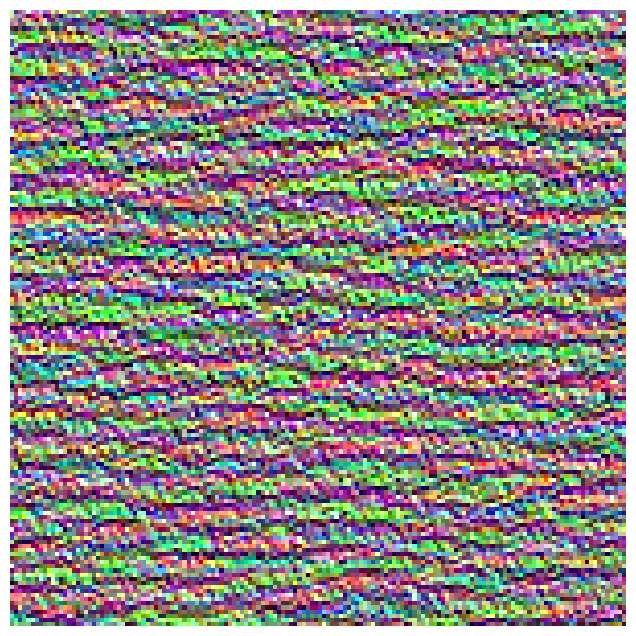

In [20]:
plt.axis('off')
plt.imshow(deprocess_image(generate_filter_pattern(filter_index=2)));

Note: typo in book, I believe that they are discussing filter 2 in `block3_sepconv1`

Since we are using the same pretrained model, should see same results here.  The filter 2 in the
`block3_sepconv1` layer is responsive to most horizontal but wavy lines, may be somewhat horizontal
features that are fur-like or water-like.

Now the fun part: you can start visualizing every filter in the layer, and even every filter in every layer in
the model.

In [21]:
# generate and save visualization for the first 64 filters in the layer
# this uses whichever layer is currently hard coded into the feature_extractor, so
# the block3_sepconv1 unless changed
all_images = []
for filter_index in range(64):
    print(f"Processing filter {filter_index}")
    image = deprocess_image(generate_filter_pattern(filter_index))
    all_images.append(image)

# prepare a blank canvas for us to paste filter visualizations on
margin = 5
n = 8
cropped_width = img_width - 25 * 2
cropped_height = img_height - 25 * 2
width = n * cropped_width + (n - 1) * margin
height = n * cropped_height + (n - 1) * margin
stitched_filters = np.zeros((width, height, 3))

# TODO: I do not like code that looks like this, refactor it at some point
# fill the picture with the saved filters
for i in range(n):
    for j in range(n):
        image = all_images[i * n + j]
        # note code shown in book is not correct, this works
        row_start = (cropped_width + margin) * i
        row_end = (cropped_width + margin) * i + cropped_width
        column_start = (cropped_height + margin) * j
        column_end = (cropped_height + margin) * j + cropped_height
        
        stitched_filters[row_start: row_end, column_start: column_end, :] = image

# save the canvas to disk
keras.utils.save_img(
    f"../figures/filters-for-layer-{layer_name}.png",
    stitched_filters
)

Processing filter 0
Processing filter 1
Processing filter 2
Processing filter 3
Processing filter 4
Processing filter 5
Processing filter 6
Processing filter 7
Processing filter 8
Processing filter 9
Processing filter 10
Processing filter 11
Processing filter 12
Processing filter 13
Processing filter 14
Processing filter 15
Processing filter 16
Processing filter 17
Processing filter 18
Processing filter 19
Processing filter 20
Processing filter 21
Processing filter 22
Processing filter 23
Processing filter 24
Processing filter 25
Processing filter 26
Processing filter 27
Processing filter 28
Processing filter 29
Processing filter 30
Processing filter 31
Processing filter 32
Processing filter 33
Processing filter 34
Processing filter 35
Processing filter 36
Processing filter 37
Processing filter 38
Processing filter 39
Processing filter 40
Processing filter 41
Processing filter 42
Processing filter 43
Processing filter 44
Processing filter 45
Processing filter 46
Processing filter 47
Pr

Here is the image we just saved to the figures subdirectory of our project.

![Block3 depthwise separable convolution 1 filters](../figures/filters-for-layer-block3_sepconv1.png)

These filter visualizations tell you a lot about how convnet layers see the world.

Each layer in a convnet learns a collection of filters such that their inputs can be expressed as a combination of filters.  The filters
in these convnet filter banks get increasing complex and refined as you go deeper in the model:

- The filters from the first layers in the model encode simple directional edges
  and colors (or colored edges, in some cases).
- The filters from layers a bit further up the stack, such as `block4_sepconv1`,
  encode simple textures made from combinations of edges and colors.
- The filters in higher layers begin to resemble textures found in natural images:
  feathers, eyes, leaves, and so on.

### 9.4.3 Visualizing Heatmaps of Class Activation

This general category of techniques is called class activation map (CAM) visualization,
and it consists of producing heatmaps of class activation over input images.

A class activation heatmap is a 2D grid of scores associated with a specific output class,
computed for every location in any input image, indicating how important each location
is with respect to the class under consideration.

Grad-CAM consists of taking the output feature map of a convolution layer, given
an input image, and weighing every channel in that feature map by the gradient of
the class with respect to the channel.

Intuitively, one way to understand this trick is to
imagine that you’re weighting a spatial map of “how intensely the input image activates
different channels” by “how important each channel is with regard to the class,”
resulting in a spatial map of “how intensely the input image activates the class.”

We'll demonstrate again using the pretrained Xception model.  Note we need to
include the top of the model, the densely connected classifier, because
we want to know the predicted output class for this example.

In [22]:
# keep the densely connected classifier on top, don't discard
model = keras.applications.xception.Xception(weights="imagenet")

91884032/91884032 ━━━━━━━━━━━━━━━━━━━━ 16s 0us/step


In the example we'll use the following image, again not part of the original ImageNet, and downloaded from
an amazonaws bucket.  Let's convert this image into something
that the Xception model can read.  The model was trained on images of size `299 x 299`, preprocessed according
to a few rules that are packaged in the `preprocess_input` utility function we saw before.  So we need to load the
image, resize it to the needed size, convert it to a NumPy `float32` tensor, and applying the preprocessing rules.

In [23]:
# download the image and store it locally under the path img_path
img_path = keras.utils.get_file(
    fname="elephant.jpg",
    origin="https://img-datasets.s3.amazonaws.com/elephant.jpg")
print(img_path)

733657/733657 ━━━━━━━━━━━━━━━━━━━━ 1s 1us/step
/home/vscode/.keras/datasets/elephant.jpg


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


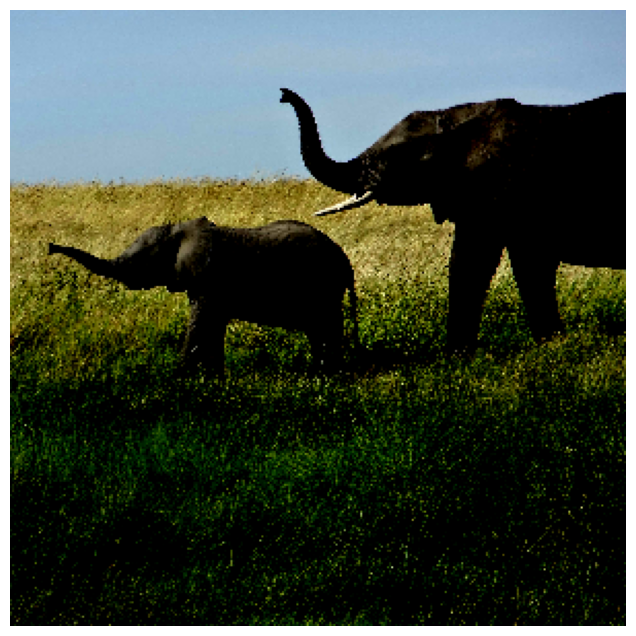

In [24]:
def get_img_array(img_path, target_size):
    """Do conversions to resize image, convert to a NumPy
    tensor, and do expected xception preprocessing rules.
    """
    # get a PIL image and resize it to needed target size
    img = keras.utils.load_img(img_path, target_size=target_size)
    # return a float32 NumPy array of shape (299, 299, 3)
    array = keras.utils.img_to_array(img)
    # add a dimension for sample dimension, so we have a (1, 299, 299, 3) shaped tensor suitable
    # as input for a model
    array = np.expand_dims(array, axis=0)
    # preprocess the batch (does color-wise normalization
    array = keras.applications.xception.preprocess_input(array)
    return array

# note the test picture looks darker and is downsampled when we plot here,
# from the transformations just performed. for comparison look at the original large sized image.
img_array = get_img_array(img_path, target_size=(299, 299))
plt.imshow(img_array[0])
plt.axis("off");

You can now run the pretrained network on the image and decode its prediction vector back to a
human-readable format (e.g. this is the top-3 category predictions Xception makes for this image for
the ImageNet competition):

In [25]:
preds = model.predict(img_array)
print(keras.applications.xception.decode_predictions(preds, top=3)[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 3us/step
[('n02504458', 'African_elephant', 0.87017745), ('n01871265', 'tusker', 0.07680043), ('n02504013', 'Indian_elephant', 0.023522502)]


The top three classes predicted for this image are as follows:

1. African elephant (with 87% probability)
2. Tusker (with 7% probability)
3. Indian elephant (with 2% probability).

The network has correctly recognized the image as containing an (undetermined) quantity
of African elephants.

The entry that was maximally activated in the 1000 sized `softmax` output
from the Xception multi-class classifier, the one corresponding to the
"African elephant" class, is at index 386:

In [26]:
np.argmax(preds[0])

386

But on to our example.  To visualize which parts of the image are the most "African-elephant-like", we'll set up the
Grad-CAM process.

First we create a model that maps the input image to the activations of the last convolutional layer
e.g. like before a model that extracts the output of the layer we want to examine given the inputs.

In [27]:
# setting up a model that returns the last convolutional output
last_conv_layer_name = "block14_sepconv2_act"
last_conv_layer = model.get_layer(last_conv_layer_name)
last_conv_layer_model = keras.Model(model.inputs, last_conv_layer.output)

Second, we create a model that will map the activations of the last convolutional layer to the final
class predictions.

In [28]:
# reapplying the classifier on top of the last convolutional output
classifier_layer_names = [
    "avg_pool",
    "predictions",
]

classifier_input = keras.Input(shape=last_conv_layer.output.shape[1:])
x = classifier_input
for layer_name in classifier_layer_names:
    x = model.get_layer(layer_name)(x)
classifier_model = keras.Model(classifier_input, x)

Then we compute the gradient of the top predicted class for our input image with respect
to the activations of the last convolution layer.  

**TODO**: I got a UserWarning running this

```
/opt/conda/lib/python3.12/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_168']
Received: inputs=Tensor(shape=(1, 299, 299, 3))
  warnings.warn(msg)
```

Not sure why, the shape of input and the image tensor matches.  Need to see what the `keras_tensor_168` expected here refers to.

In [29]:
# retrieving the gradients of the top predicted class
with tf.GradientTape() as tape:
    # compute the activations of the last conv layer and make the tape watch it
    # e.g. create tf variable with output of last convolution layer before the
    # dense predictors, and have tape watch that variable so we can compute gradients
    last_conv_layer_output = last_conv_layer_model(img_array)
    tape.watch(last_conv_layer_output)

    # retrieve the activation channel corresponding to the top
    # predicted class
    preds = classifier_model(last_conv_layer_output)
    top_pred_index = tf.argmax(preds[0])
    top_class_channel = preds[:, top_pred_index]

# this is the gradient of the top predicted class with regard to the output
# feature map of the last convolutional layer
grads = tape.gradient(top_class_channel, last_conv_layer_output)

/opt/conda/lib/python3.12/site-packages/keras/src/models/functional.py:258: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_168']
Received: inputs=Tensor(shape=(1, 299, 299, 3))
  warnings.warn(msg)


Now we apply pooling and importance weighting to the gradient tensor to obtain our
heatmap of class activation.

In [30]:
# this is a vector where each entry is the mean intensity of the gradient for a 
# given channel. It quantifies the importance of each channel with regard to the top
# predicted class
pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2)).numpy()

last_conv_layer_output = last_conv_layer_output.numpy()[0]

# multiply each channel in the output of the last convolutional layer
# by how important this channel is
for i in range(pooled_grads.shape[-1]):
    last_conv_layer_output[:, :, i] *= pooled_grads[i]

# the channel-wise mean of the resulting feature map is our heatmap of
# class activation.
heatmap = np.mean(last_conv_layer_output, axis=-1)

For visualization purposes we'll also need to normalize the heatmap between 0 and 1.
The result is shown here.

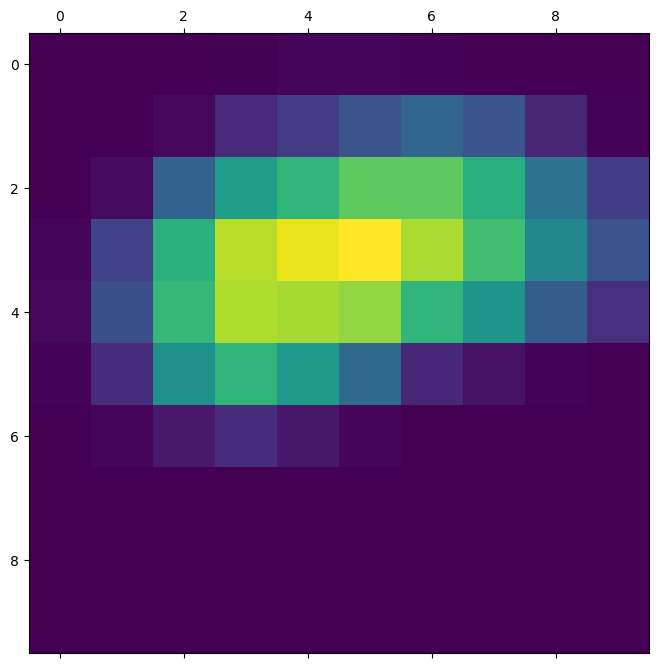

In [31]:
heatmap = np.maximum(heatmap, 0)
heatmap /= np.max(heatmap)
plt.matshow(heatmap);

Finally, let's generate an image that superimposes the original image on the heatmap we just obtained.

In [32]:
import matplotlib

# load the original image
img = keras.utils.load_img(img_path)
img = keras.utils.img_to_array(img)

# rescale the heatmap to the range 0-255 and convert to int
heatmap = np.uint8(255 * heatmap)

# use the "jet" colormap to recolorize the heatmap
jet = matplotlib.colormaps["jet"]
jet_colors = jet(np.arange(256))[:, :3]
jet_heatmap = jet_colors[heatmap]

# create an image that contains the recolorized heatmap
jet_heatmap = keras.utils.array_to_img(jet_heatmap)
jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
jet_heatmap = keras.utils.img_to_array(jet_heatmap)

# superimpose the heatmap and the original image
superimposed_img = jet_heatmap * 0.4 + img
superimposed_img = keras.utils.array_to_img(superimposed_img)
save_path = "../figures/elephant-cam.jpg"
superimposed_img.save(save_path)

Here is the image with the superimposed CAM heatmap we just saved:

![African elephant class activation (heat)map (CAM) over the test picture](../figures/elephant-cam.jpg)

This visualization technique answers two important questions

1. Why did the network think this image contained an African elephant?
2. Where is the African elephant located in the picture?

In particular, it’s interesting to note that the ears of the elephant calf are strongly activated:
this is probably how the network can tell the difference between African and
Indian elephants.

# Chapter Summary

Some of the important things to keep in mind from our discussion on advanced deep learning for computer vision

<font color='blue'>

- There are three essential computer vision tasks you can do with deep learning:
  image classification, image segmentation, and object detection.
- Following modern convnet architecture best practices will help you get the
  most out of your models. Some of these best practices include using residual
  connections, batch normalization, and depthwise separable convolutions.
- The representations that convnets learn are easy to inspect—convnets are the
  opposite of black boxes!
- You can generate visualizations of the filters learned by your convnets, as well as
  heatmaps of class activity.